In [12]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os                       
import torch
from torch import nn
from torch.utils.data import DataLoader
from scipy.ndimage import convolve

# Set device to GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())

# Directory for storing datasets
save_dir = "Data"

# Path to functions
from python.functions import *

GPU available:  True


# 1. Data Loading

Load the LFW (Labeled Faces in the Wild) dataset. The dataset will be cached locally to avoid repeated downloads.

In [13]:
# Try to load cached dataset, otherwise download from sklearn
try:
    img = np.load(os.path.join(save_dir, 'Img.npy'))
    print("Image dataset loaded from cache.")
except Exception as e:
    # Download LFW dataset with minimum 30 faces per person
    from sklearn.datasets import fetch_lfw_people
    min_faces_per_person = 30
    faces = fetch_lfw_people(min_faces_per_person=min_faces_per_person)
    print("Image dataset downloaded from sklearn.")
    
    # Extract images and save for future use
    img = faces.images
    np.save(os.path.join(save_dir, 'Img.npy'), img)
    print("Image dataset cached to disk.")

Image dataset loaded from cache.


# 2. Image Preprocessing

Convert images to normalized grayscale values (0-255 range) for consistent processing.

In [14]:
def grayscale(image):
    """
    Normalize image pixel values to 0-255 range.
    
    Args:
        image: Input image array
        
    Returns:
        Normalized image with values in [0, 255]
    """
    X, Y = np.shape(image)
    
    # Find min and max values for normalization
    m = image.min()
    M = image.max()

    # Normalize each pixel to 0-255 range
    for i in range(X):
        for j in range(Y):  
            image[i, j] = (image[i, j] * 255) / (M) if M > 0 else 0

    return image

# Apply grayscale normalization to all images
img_grayscale = np.array([grayscale(image) for image in img])

# 3. Data Augmentation - Adding blur

Blur clean images to create training pairs (blurred → clean) for the deblurring model.

In [15]:
def add_blur(image, sigma=0.5):
    """
    Add Gaussian blur to an image using 2D Gaussian convolution.
    
    Args:
        image: Input image as numpy array (H x W)
        sigma: Controls blur strength. Higher = more blur
        
    Returns:
        Blurred image as numpy array
    """
    
    # Determine kernel size based on sigma (common rule: kernel_size ~= 6*sigma)
    kernel_size = int(6 * sigma)
    if kernel_size % 2 == 0:
        kernel_size += 1  # Ensure odd kernel size
    kernel_size = max(3, kernel_size)  # Minimum size of 3
    
    # Create 1D Gaussian kernel
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    gaussian_1d = np.exp(-0.5 * (ax / sigma) ** 2)
    gaussian_1d /= gaussian_1d.sum()  # Normalize
    
    # Create 2D Gaussian kernel using outer product
    gaussian_2d = np.outer(gaussian_1d, gaussian_1d)
    
    # Apply 2D Gaussian convolution
    blurred = convolve(image, gaussian_2d, mode='reflect')
    
    return blurred

# Create blurred versions of all images
img_blurred = np.zeros_like(img_grayscale)

for i in range(len(img_grayscale)):
    img_blurred[i] = add_blur(img_grayscale[i], sigma=1)

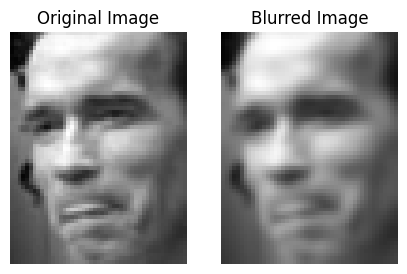

In [16]:
# Visualize the effect of noise on a sample image
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_grayscale[1], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Blurred Image")
plt.imshow(img_blurred[1], cmap='gray')
plt.axis('off')

plt.show()

# 4. Data Preparation for Training

Create PyTorch datasets and dataloaders with appropriate transformations.

In [17]:
# Split the dataset: 1500 images for training, rest for testing
train_data = img_blurred[:1500]
train_targets = img_grayscale[:1500]

test_data = img_blurred[1500:]
test_targets = img_grayscale[1500:]

# Create datasets with transforms applied
train_dataset = MyDataset(train_data, train_targets, 
                         transform=add_channel, 
                         target_transform=add_channel)
test_dataset = MyDataset(test_data, test_targets,
                        transform=add_channel,
                        target_transform=add_channel)

# Create dataloaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. DnCNN Model Architecture

Implementing DnCNN (Denoising Convolutional Neural Network), which learns to predict the **noise** rather than the clean image directly. This approach has been shown to be more effective for denoising tasks.

**Architecture:**
- Input: Noisy image (1 channel)
- 1 Conv layer (64 filters, 3×3) + ReLU
- 15 Conv layers (64 filters, 3×3) + Batch Normalization + ReLU  
- 1 Conv layer (1 filter, 3×3) → outputs predicted noise
- Final output: Clean image = Noisy image - Predicted noise

In [18]:
def train(dataloader, model, loss_fn, optimizer):
    """
    Training function for DnCNN using residual learning.
    
    The model predicts the noise, which is then subtracted from the noisy input
    to obtain the clean image. This is more effective than directly predicting
    the clean image.
    
    Args:
        dataloader: PyTorch DataLoader with training batches
        model: DnCNN model
        loss_fn: Loss function (e.g., MSE)
        optimizer: Optimizer (e.g., Adam)
        
    Returns:
        Average training loss for the epoch
    """
    model.train()
    total_loss = 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        
        # Predict noise (residual learning)
        noise = model(X)
        
        # Reconstruct clean image by subtracting predicted noise
        pred = X - noise
        
        # Compute loss between predicted clean image and ground truth
        loss = loss_fn(pred, y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

layers = []

# Layer 1: Conv(3x3, 64 filters) + ReLU
# Input: (batch, 1, H, W) → Output: (batch, 64, H, W)
layers.append(nn.Conv2d(1, 64, kernel_size=3, padding=1))
layers.append(nn.ReLU(inplace=True))

# Layers 2-16: Conv(3x3, 64 filters) + BatchNorm + ReLU
# These layers learn hierarchical features while maintaining spatial dimensions
for _ in range(15):
    layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(64))
    layers.append(nn.ReLU(inplace=True))

# Layer 17: Conv(3x3, 128 filters) + BatchNorm + ReLU
layers.append(nn.Conv2d(64, 128, kernel_size=3, padding=1))
layers.append(nn.BatchNorm2d(128))
layers.append(nn.ReLU(inplace=True))

# Layer 18-20: Conv(3x3, 128 filters) + BatchNorm + ReLU
for _ in range(3):
    layers.append(nn.Conv2d(128, 128, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(128))
    layers.append(nn.ReLU(inplace=True))

# Layer 21: Conv(3x3, 64 filters) + BatchNorm + ReLU
layers.append(nn.Conv2d(128, 64, kernel_size=3, padding=1))
layers.append(nn.BatchNorm2d(64))
layers.append(nn.ReLU(inplace=True))

# Layer 22: Conv(3x3, 1 filters) → Output: sharp image
layers.append(nn.Conv2d(64, 1, kernel_size=3, padding=1))

# Create model
cnn = nn.Sequential(*layers).to(device)

# Loss function: Mean Squared Error between predicted and target clean images
loss_fn = nn.MSELoss()

# Optimizer: Adam with learning rate 1e-3
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

# 6. Model Training

Train the DnCNN model for 50 epochs and visualize the training loss progression.

Epoch 50/50
Training completed! Final loss: 0.000082


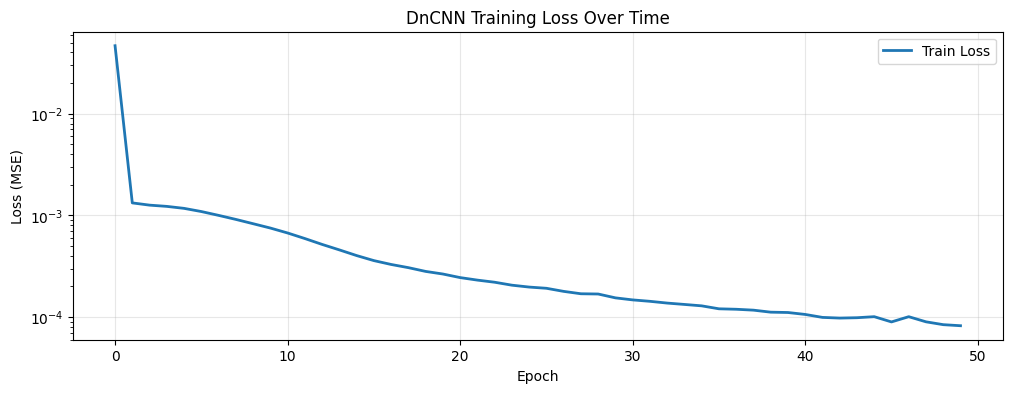

In [19]:
# Training loop
epochs = 50
train_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}", end="\r")
    train_loss = train(train_loader, cnn, loss_fn, optimizer)
    train_losses.append(train_loss)

print(f"\nTraining completed! Final loss: {train_losses[-1]:.6f}")

# Plot training loss curve
plt.figure(figsize=(12, 4))
plt.semilogy(train_losses, label='Train Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('DnCNN Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Model Evaluation

Test the trained DnCNN model on a sample image to visualize denoising performance.

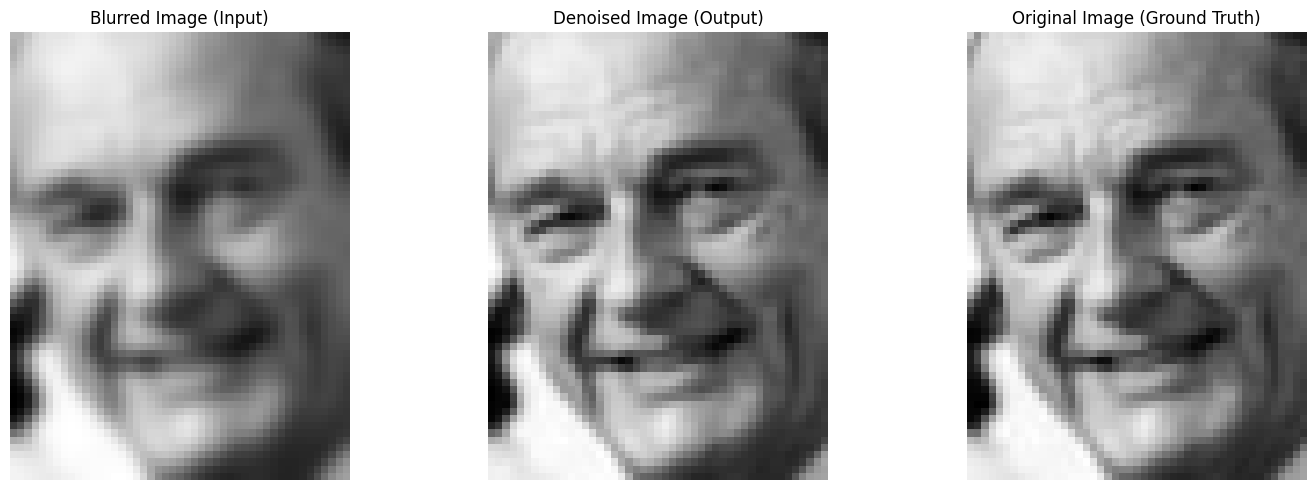

In [20]:
# Select a test image
idx = 71

# Denoise the image using the trained model
cnn.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient computation for inference
    # Prepare noisy image as model input
    blurred = add_channel(img_blurred[idx]).unsqueeze(0).to(device)
    
    # Predict noise using DnCNN
    noise_pred = cnn(blurred)
    
    # Reconstruct clean image: noisy - predicted_noise
    denoised = torch.clamp(blurred - noise_pred, 0, 1).cpu().squeeze()

# Visualize: Blurred → Denoised → Original
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_blurred[idx], cmap='gray')
plt.title("Blurred Image (Input)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised Image (Output)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_grayscale[idx], cmap='gray')
plt.title("Original Image (Ground Truth)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 8. Save the model

In [21]:
# Save the model's learned parameters
torch.save(cnn, 'CNN/Blur_cnn_model.pth')